### Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Import Gambar

In [2]:
img = cv2.imread('Assets/Nama1.jpeg')
if img is None:
    print("Citra tidak dapat dimuat. Pastikan path gambar benar.")
else:
    print("Citra berhasil dimuat.")

Citra berhasil dimuat.


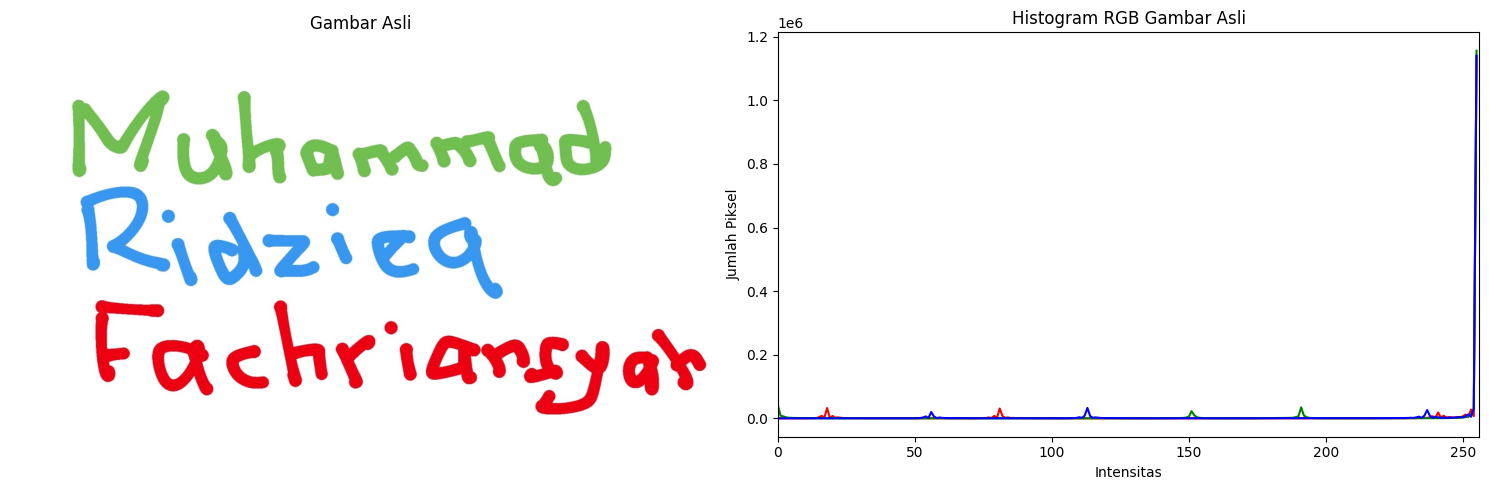

In [3]:
output_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axis = plt.subplots(1, 2, figsize=(15, 5))

# Menampilkan gambar asli
axis[0].imshow(output_rgb)
axis[0].set_title("Gambar Asli")
axis[0].axis('off')

# Menampilkan histogram
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    axis[1].plot(hist, color=col)
axis[1].set_xlim([0, 256])
axis[1].set_title("Histogram RGB Gambar Asli")
axis[1].set_xlabel("Intensitas")
axis[1].set_ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

### Mendeteksi Warna

In [4]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# ==== Deteksi Warna ====
# === Merah
deteksiMerah = cv2.bitwise_or(
    cv2.inRange(hsv, np.array([0, 70, 50]), np.array([10, 255, 255])),
    cv2.inRange(hsv, np.array([170, 70, 50]), np.array([180, 255, 255]))
)
# === Hijau
deteksiHijau = cv2.inRange(hsv, np.array([36, 50, 50]), np.array([89, 255, 255]))
# === Biru
deteksiBiru = cv2.inRange(hsv, np.array([90, 50, 50]), np.array([130, 255, 255]))

### Deteksi Merah

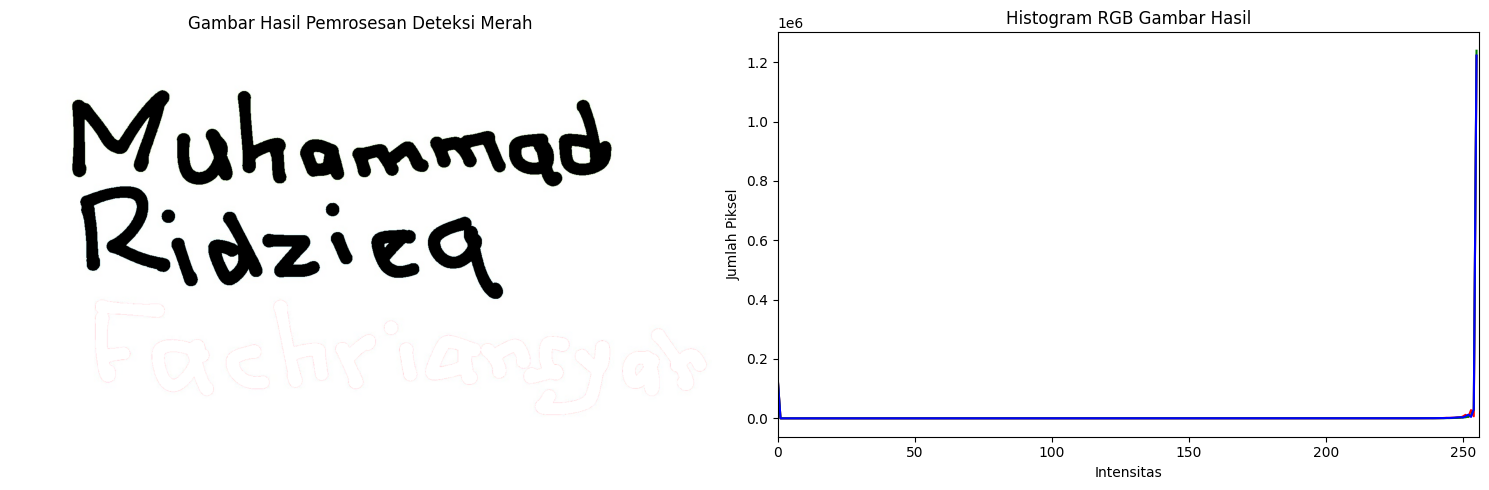

In [5]:
biruHijau = cv2.bitwise_or(deteksiHijau, deteksiBiru)

hasil = img.copy()
hasil[deteksiMerah > 0] = [255, 255, 255]
hasil[biruHijau > 0] = [0, 0, 0]

# Konversi ke RGB untuk plt
output_rgb = cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB)

fig, axis = plt.subplots(1, 2, figsize=(15, 5))

# Menampilkan gambar hasil
axis[0].imshow(output_rgb)
axis[0].set_title("Gambar Hasil Pemrosesan Deteksi Merah")
axis[0].axis('off')

# Menampilkan histogram
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist = cv2.calcHist([hasil], [i], None, [256], [0, 256])
    axis[1].plot(hist, color=col)
axis[1].set_xlim([0, 256])
axis[1].set_title("Histogram RGB Gambar Hasil")
axis[1].set_xlabel("Intensitas")
axis[1].set_ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

### Deteksi Biru

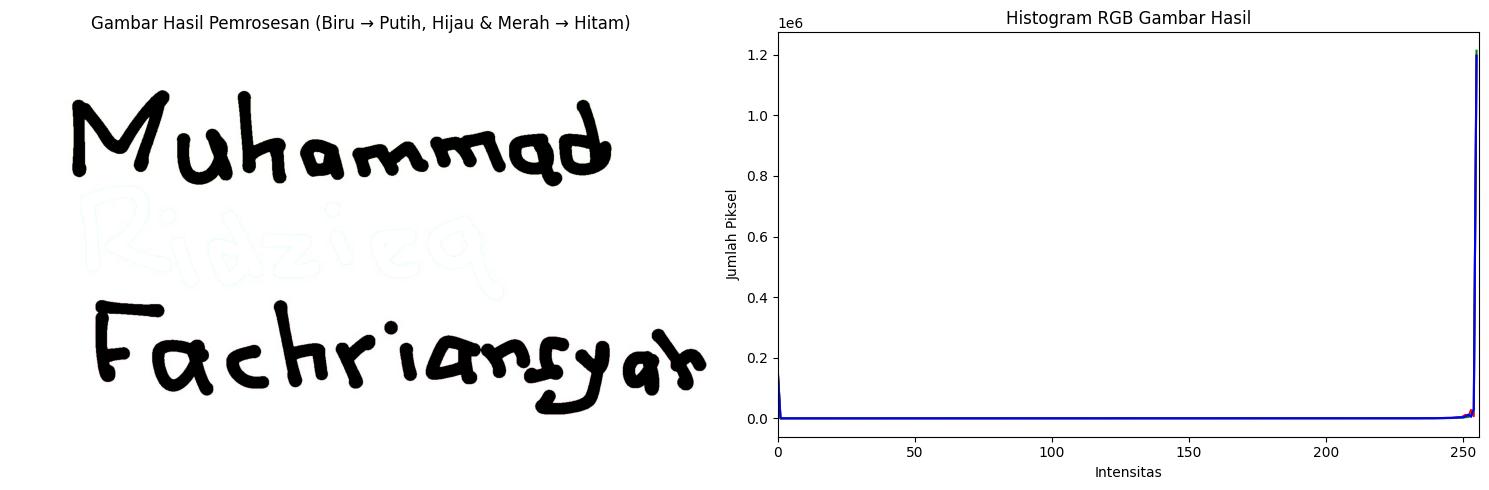

In [6]:
merahHijau = cv2.bitwise_or(deteksiHijau, deteksiMerah)

hasil = img.copy()
hasil[deteksiBiru > 0] = [255, 255, 255]
hasil[merahHijau > 0] = [0, 0, 0]

# Konversi ke RGB untuk plt
output_rgb_1 = cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB)

fig, axis = plt.subplots(1, 2, figsize=(15, 5))

# Menampilkan gambar hasil pemrosesan
axis[0].imshow(output_rgb_1)
axis[0].set_title("Gambar Hasil Pemrosesan (Biru → Putih, Hijau & Merah → Hitam)")
axis[0].axis('off')

# Menampilkan histogram
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist = cv2.calcHist([hasil], [i], None, [256], [0, 256])
    axis[1].plot(hist, color=col)
axis[1].set_xlim([0, 256])
axis[1].set_title("Histogram RGB Gambar Hasil")
axis[1].set_xlabel("Intensitas")
axis[1].set_ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

### Deteksi Hijau

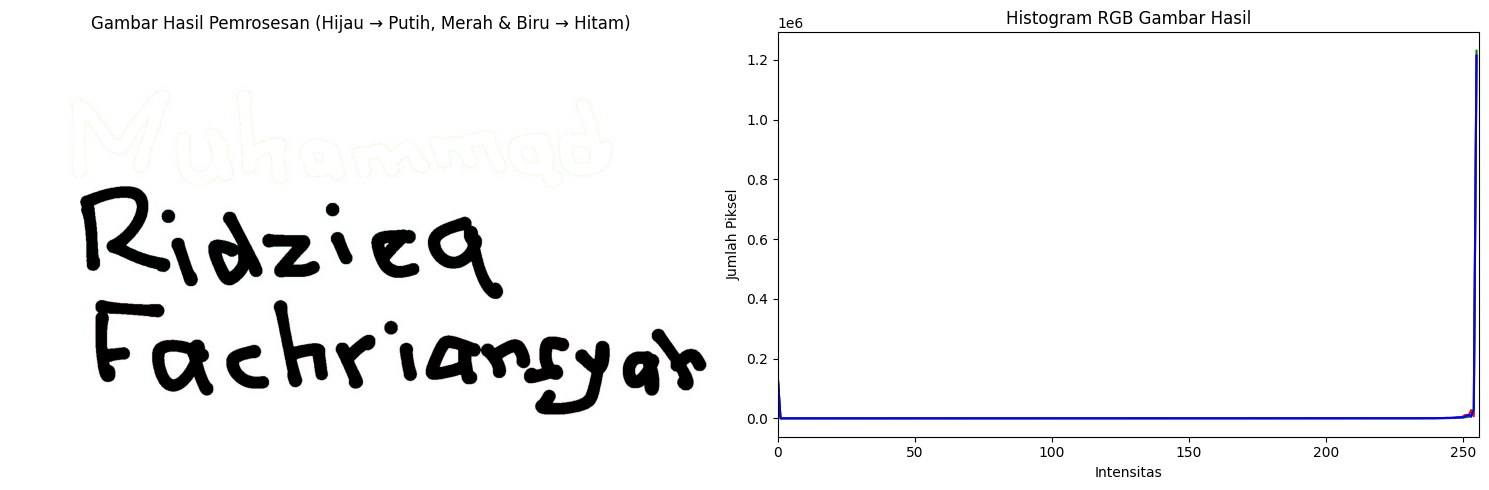

In [7]:
merahBiru = cv2.bitwise_or(deteksiBiru, deteksiMerah)

hasil = img.copy()
hasil[deteksiHijau > 0] = [255, 255, 255]
hasil[merahBiru > 0] = [0, 0, 0]

# Konversi ke RGB untuk plt
output_rgb_2 = cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB)

fig, axis = plt.subplots(1, 2, figsize=(15, 5))

# Menampilkan gambar hasil pemrosesan
axis[0].imshow(output_rgb_2)
axis[0].set_title("Gambar Hasil Pemrosesan (Hijau → Putih, Merah & Biru → Hitam)")
axis[0].axis('off')

# Menampilkan histogram
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist = cv2.calcHist([hasil], [i], None, [256], [0, 256])
    axis[1].plot(hist, color=col)
axis[1].set_xlim([0, 256])
axis[1].set_title("Histogram RGB Gambar Hasil")
axis[1].set_xlabel("Intensitas")
axis[1].set_ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()
